In [21]:
import sys
print(sys.path)


import aqua

from aqua.batchAQUA_general import batchAQUA
from aqua.utils import *
from aqua.stimulus import *

import numpy as np
import matplotlib.pyplot as plt

['/home/liam/anaconda3/envs/aqua/lib/python314.zip', '/home/liam/anaconda3/envs/aqua/lib/python3.14', '/home/liam/anaconda3/envs/aqua/lib/python3.14/lib-dynload', '', '/home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages', '/home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/setuptools/_vendor']


In [22]:
'''
Will test the STA protocol on filtered white noise injected into the RS_int and RS_res neurons

- need to find the threshold
- Apply a filtered white noise stimulus to this threshold current.

'''

'\nWill test the STA protocol on filtered white noise injected into the RS_int and RS_res neurons\n\n- need to find the threshold\n- Apply a filtered white noise stimulus to this threshold current.\n\n'

## Try again with filtered white noise

In [23]:
### Try again with filtered white noise...

RS_int = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

RS_res = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

N_neurons = 50

T = 2    # ms
dt = 0.1    # ms
N_iter = int(1000.*T/dt)

params_int = []
params_res = []

for i in range(N_neurons):
    params_int.append(RS_int)
    params_res.append(RS_res)


batch_int = batchAQUA(params_int)
batch_res = batchAQUA(params_res)

# get threshold and initialisation values
threshold_int, steady_int = batch_int.get_threshold(idx = 0)
threshold_res, steady_res = batch_res.get_threshold(idx = 0)

#reuse threshold and steady-state from before
x_start_int = np.full((N_neurons, 3), fill_value = steady_int)
x_start_res = np.full((N_neurons, 3), fill_value = steady_res)
t_start = np.zeros(N_neurons)

# initialise
batch_int.Initialise(x_start_int, t_start)
batch_res.Initialise(x_start_res, t_start)

# create filtered white noise input
noise_scale = 20    # amplitude     
f_cutoff = 8       # the cutoff frequency
I_noise = np.array([filtered_white_noise_fast(T, dt, amplitude = noise_scale, cutoff = f_cutoff) for i in range(N_neurons)])

#I_noise has mean 0 so we scale up to threshold
I_int = threshold_int + I_noise
I_res = threshold_res + I_noise

# simulate each neuron with noise
X_int, T, spikes_int = batch_int.update_batch(dt, N_iter, I_int)
X_res, T, spikes_res = batch_res.update_batch(dt, N_iter, I_res)


- - threshold - -


100%|██████████| 59999/59999 [00:07<00:00, 7669.35it/s]


- - threshold - -


100%|██████████| 19999/19999 [00:02<00:00, 8022.33it/s]


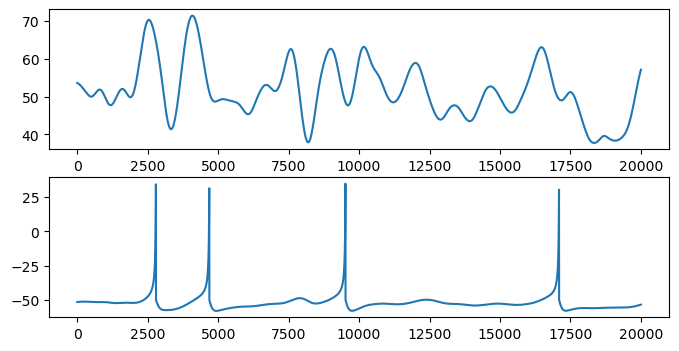

In [24]:

fig, ax = plt.subplots(2, 1, figsize = (8, 4))
idx = 15

ax[0].plot(I_int[idx])

ax[1].plot(X_int[idx, 0, :])



- - STA - - 


100%|██████████| 50/50 [00:00<00:00, 21929.85it/s]


- - STA - - 


100%|██████████| 50/50 [00:00<00:00, 46968.69it/s]


Text(0.5, 0.98, 'STA from white noise input')

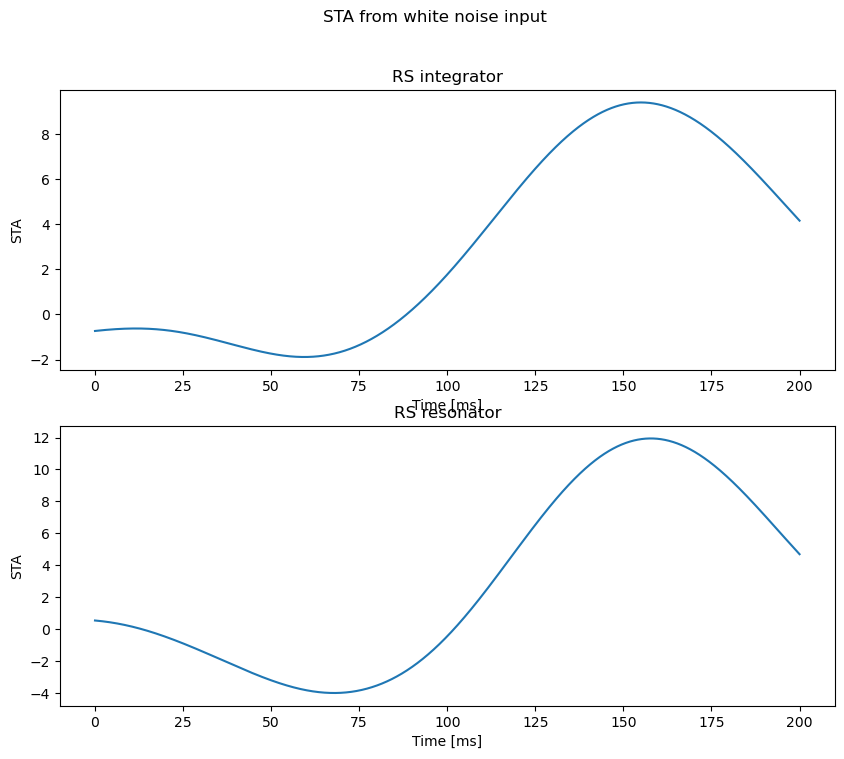

In [25]:
# calculate the STA and plot
window = 2000
STA_int = STA(spikes_int, I_int, dt, window = window)
STA_res = STA(spikes_res, I_res, dt, window = window)

fig, ax = plt.subplots(2, 1, figsize = (10, 8))

time = np.linspace(0, dt*window, window)

ax[0].plot(time, np.mean(STA_int, axis = 0))
ax[1].plot(time, np.mean(STA_res, axis = 0))

ax[0].set_xlabel('Time [ms]')
ax[0].set_ylabel('STA')
ax[0].set_title('RS integrator')

ax[1].set_xlabel('Time [ms]')
ax[1].set_ylabel('STA')
ax[1].set_title('RS resonator')

fig.suptitle("STA from white noise input")

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

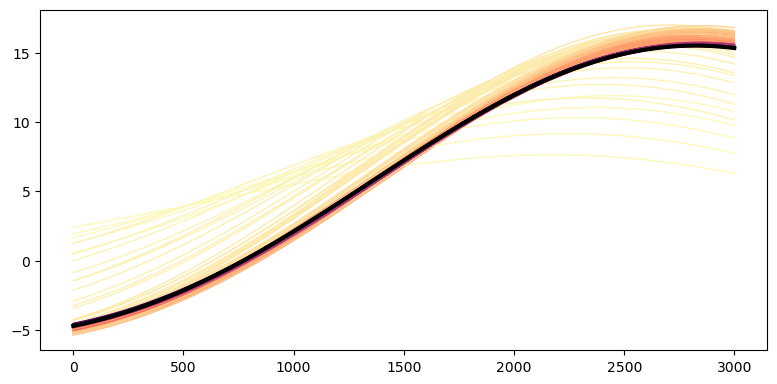

In [29]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

with open(".//RS_intHD_uniform//RS_intHD_uniform_2.0_STA.pickle", "rb") as file:
    data = pickle.load(file)

print(data.keys())


N_neurons = len(data)
print(N_neurons)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))
fig.tight_layout()

# Define the colormap and normalization
cmap_base = plt.get_cmap('magma')
aut_curr = np.sort(np.array([data[n]['autapse current'] for n in range(N_neurons)])) # Sorted for consistent mapping
aut_curr = aut_curr[~np.isnan(aut_curr)]
new_colors = cmap_base(np.linspace(0., 1.0, N_neurons))

for i in range(N_neurons-1, -1, -1):
    if i == 0:
        colour = (0, 0, 0)
        linewidth = 3
    else:
        neuron_autapse = data[i]['autapse current']
        idx = np.argwhere(aut_curr == neuron_autapse)[0]
        colour = new_colors[idx]
        linewidth = 1

    ax.plot(data[i]['sta'], color = colour, linewidth = linewidth)

    

